# Experiment 2: Reversible Midpoint integrator

**Objective.** Train the same ~20M-parameter GPT with a reversible (invertible)
transformer stack, using the paper's midpoint discretization (Eq 4), and compare
memory, throughput, and loss against the baseline.

**Hypothesis.** Because the stack stores only the final state and reconstructs
intermediates by inversion, activation memory is constant in depth, allowing a
larger batch within the same device memory at the cost of recompute.

**Procedure.**
- Verify invertibility and custom-backward parity.
- Measure activation memory as a function of depth.
- Train at the shared anchor `B_FIXED = 196`, then probe and train at the
  auto-detected `B_MAX`.

**Reference.** Gal, Eliasof, Turek, Ascher, Treister, Haber. *Reversing Large Language Models for Efficient Training and Fine-Tuning.* arXiv:2512.02056. https://arxiv.org/abs/2512.02056

## Environment setup

The runtime dependencies are installed and the environment is printed, so the
torch/CUDA versions are captured in the notebook output.

In [1]:
!pip install -q torch datasets transformers tqdm matplotlib

import torch
print("torch", torch.__version__, "| cuda", torch.version.cuda,
      "| mps", torch.backends.mps.is_available())


torch 2.11.0+cu128 | cuda 12.8 | mps False


## 1. Data preparation

The TinyStories corpus is tokenized with the GPT-2 BPE tokenizer and written to
raw `uint16` shards (`data/train.bin`, `data/val.bin`). An `EOT` token (50256) is
inserted between stories. Tokenization is streamed and multi-threaded to keep
host RAM low, and is skipped if the shards already exist.

In [2]:
import os

# Disable the tokenizer's own internal threads so parallelism is driven by the
# ThreadPoolExecutor below (avoids oversubscription and works on Colab + local).
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from array import array
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer

EOT = 50256  # <|endoftext|> separator between stories


def _enough(path, need):
    return os.path.exists(path) and os.path.getsize(path) >= need * 2


def _write(ds, tok, path, max_tokens, encode_batch=2000, num_threads=None):
    """Tokenize in parallel across threads, streaming the dataset (low RAM)."""
    if num_threads is None:
        num_threads = os.cpu_count() or 4

    def encode(texts):
        ids = array("H")  # uint16 accumulator (compact 2B/token)
        for enc in tok(texts, add_special_tokens=False)["input_ids"]:
            ids.extend(enc)
            ids.append(EOT)
        return ids

    buf = array("H")
    window = num_threads * 2
    pbar = tqdm(total=max_tokens, desc=f"Tokenizing {os.path.basename(path)}")

    batches = ds.iter(batch_size=encode_batch)
    with ThreadPoolExecutor(max_workers=num_threads) as ex:
        while len(buf) < max_tokens:
            futs = []
            for _ in range(window):
                try:
                    batch = next(batches)
                except StopIteration:
                    break
                futs.append(ex.submit(encode, batch["text"]))
            if not futs:
                break
            for f in futs:
                res = f.result()
                buf.extend(res)
                pbar.update(len(res))
    pbar.close()

    buf = buf[:max_tokens]
    with open(path, "wb") as f:
        buf.tofile(f)  # raw uint16 bytes
    print(f"Wrote {len(buf):,} tokens to {path}")


def prepare_data(data_dir="data", train_tokens=51_000_000, val_tokens=1_000_000,
                 encode_batch=2000, num_threads=None):
    os.makedirs(data_dir, exist_ok=True)
    train_path = os.path.join(data_dir, "train.bin")
    val_path = os.path.join(data_dir, "val.bin")

    tok = AutoTokenizer.from_pretrained("gpt2")

    if not _enough(train_path, train_tokens):
        print("Loading TinyStories train...")
        ds = load_dataset("roneneldan/TinyStories", split="train")
        _write(ds, tok, train_path, train_tokens, encode_batch, num_threads)
    else:
        print("train.bin already prepared.")

    if not _enough(val_path, val_tokens):
        print("Loading TinyStories validation...")
        ds = load_dataset("roneneldan/TinyStories", split="validation")
        _write(ds, tok, val_path, val_tokens, encode_batch, num_threads)
    else:
        print("val.bin already prepared.")

    return train_path, val_path


prepare_data(data_dir="data", train_tokens=51_000_000, val_tokens=1_000_000)
print("Data ready.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Tokenizing train.bin:   0%|          | 0/51000000 [00:00<?, ?it/s][transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1039 > 1024). Running this sequence through the model will result in indexing errors
Tokenizing train.bin: 54119384it [00:29, 1820597.25it/s]


Wrote 51,000,000 tokens to data/train.bin
Loading TinyStories validation...


Tokenizing val.bin: 4765918it [00:02, 1993478.26it/s]                           

Wrote 1,000,000 tokens to data/val.bin
Data ready.


## 2. Training harness and metrics

Shared constants and helpers: device selection (`cuda → mps → cpu`), seeding,
batch construction from the memory-mapped shards, the cosine LR schedule, the
validation routine (a fixed `VAL_SEED` draws identical windows at every
evaluation), peak-memory sampling, and the `train()` loop. Determinism is
requested best-effort via `cudnn.deterministic`.

In [3]:
import math
import os
import resource
import sys
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Local Mac only: cap MPS so Metal doesn't over-commit and swap.
if not any(k in os.environ for k in ("COLAB_RELEASE_TAG", "COLAB_GPU")):
    os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "1.0")
    os.environ.setdefault("PYTORCH_MPS_LOW_WATERMARK_RATIO", "0.9")

# Device selection: CUDA -> MPS (Apple Silicon) -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

# Best-effort determinism (GPU reductions may still differ).
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# --- Shared protocol constants (identical in all four notebooks) ---
SEED = 1337
VAL_SEED = 20250925        # separate, fixed RNG for validation draws
B_FIXED = 196              # fixed equal-batch anchor for baseline + reversible
BLOCK_SIZE = 512
TOKENS = 50_000_000
CE_CHUNKS = 8              # vocab head is chunked + checkpointed (see model cell)
USE_AMP = True
LR = 6e-4


@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 512
    n_embd: int = 256
    n_head: int = 8
    n_layer: int = 9
    dropout: float = 0.0


def load_data(data_dir="data"):
    train_arr = np.memmap(os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r")
    val_arr = np.memmap(os.path.join(data_dir, "val.bin"), dtype=np.uint16, mode="r")
    return train_arr, val_arr


def get_batch(arr, B, T, rng, device):
    n = len(arr) - T - 1
    ix = rng.integers(0, n, size=B)
    x = np.stack([np.asarray(arr[i:i + T], dtype=np.int64) for i in ix])
    y = np.stack([np.asarray(arr[i + 1:i + T + 1], dtype=np.int64) for i in ix])
    return torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)


class PeakMem:
    def __init__(self, device):
        self.device = device
        self.peak = 0.0
        if device.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        elif device.type == "mps":
            torch.mps.empty_cache()

    def sample(self):
        if self.device.type == "cuda":
            self.peak = torch.cuda.max_memory_allocated() / 1e6
        elif self.device.type == "mps":
            self.peak = max(self.peak, torch.mps.current_allocated_memory() / 1e6)
        else:
            raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            mb = raw / 1e6 if sys.platform == "darwin" else raw / 1e3
            self.peak = max(self.peak, mb)
        return self.peak


def reset_mem(device):
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    elif device.type == "mps":
        torch.mps.empty_cache()


def mem_now_mb(device):
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    if device.type == "mps":
        return torch.mps.current_allocated_memory() / 1e6
    raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return raw / 1e6 if sys.platform == "darwin" else raw / 1e3


def param_mem_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6


def cosine_lr(step, warmup, total, max_lr):
    if step < warmup:
        return max_lr * (step + 1) / max(warmup, 1)
    p = (step - warmup) / max(total - warmup, 1)
    return max_lr * 0.5 * (1.0 + math.cos(math.pi * min(p, 1.0)))


@torch.no_grad()
def eval_loss(model, val_arr, B, T, rng, device, ce_chunks, n_batches=40):
    model.eval()
    tot, n = 0.0, 0
    for _ in range(n_batches):
        xb, yb = get_batch(val_arr, B, T, rng, device)
        _, loss = model(xb, yb, ce_chunks)
        tot += loss.item()
        n += 1
    model.train()
    return tot / max(n, 1)


def try_batch_size(model, opt, train_arr, B, T, rng, device, use_amp, ce_chunks):
    model.zero_grad(set_to_none=True)
    opt.zero_grad(set_to_none=True)
    try:
        xb, yb = get_batch(train_arr, B, T, rng, device)
        if use_amp and device.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                _, loss = model(xb, yb, ce_chunks)
        else:
            _, loss = model(xb, yb, ce_chunks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        del xb, yb, loss
        return True
    except RuntimeError as e:
        msg = str(e).lower()
        if not any(k in msg for k in ("out of memory", "oom",
                                      "resource_exhausted", "resource exhausted")):
            raise
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()
        return False


def find_max_batch(model, opt, train_arr, T, rng, device, use_amp, ce_chunks, cap=1024):
    # Probe 1 explicitly so an untested batch size is never returned.
    if not try_batch_size(model, opt, train_arr, 1, T, rng, device, use_amp, ce_chunks):
        raise RuntimeError("even batch=1 does not fit in memory")
    lo, hi = 1, 8
    while hi <= cap:
        print(f"  probe batch={hi} ...", flush=True)
        if try_batch_size(model, opt, train_arr, hi, T, rng, device, use_amp, ce_chunks):
            lo, hi = hi, hi * 2
        else:
            break
    if hi > cap:
        return cap
    while lo + 1 < hi:
        mid = (lo + hi) // 2
        print(f"  probe batch={mid} ...", flush=True)
        if try_batch_size(model, opt, train_arr, mid, T, rng, device, use_amp, ce_chunks):
            lo = mid
        else:
            hi = mid
    return lo


def train(model, opt, batch_size, tokens, block_size, lr, train_arr, val_arr, rng, device,
          use_amp, ce_chunks, run_name, micro_batch=None, eval_every=50, log_every=25,
          ema_decay=0.95, **extra):
    B, T = batch_size, block_size
    mb = micro_batch or B
    assert B % mb == 0, "batch_size must be divisible by micro_batch"
    accum = B // mb
    total_steps = tokens // (B * T)
    warmup = min(1000, total_steps // 10)
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None

    model.train()
    mem = PeakMem(device)
    t0 = time.time()
    last_loss, last_val = float("nan"), float("nan")
    loss_ema = None
    tokens_seen = 0
    peak_tok = 0.0
    hist = {"step": [], "train": [], "val": []}

    for step in range(total_steps):
        step_t0 = time.time()
        lr_now = cosine_lr(step, warmup, total_steps, lr)
        for pg in opt.param_groups:
            pg["lr"] = lr_now
        xb, yb = get_batch(train_arr, B, T, rng, device)
        opt.zero_grad(set_to_none=True)
        last_loss = 0.0
        for a in range(accum):
            xa, ya = xb[a * mb:(a + 1) * mb], yb[a * mb:(a + 1) * mb]
            if scaler is not None:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    _, loss_a = model(xa, ya, ce_chunks)
                scaler.scale(loss_a / accum).backward()
            else:
                _, loss_a = model(xa, ya, ce_chunks)
                (loss_a / accum).backward()
            last_loss += loss_a.item() / accum
            del loss_a
        if scaler is not None:
            scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if scaler is not None:
            scaler.step(opt)
            scaler.update()
        else:
            opt.step()
        tokens_seen += B * T
        loss_ema = last_loss if loss_ema is None else ema_decay * loss_ema + (1 - ema_decay) * last_loss
        peak = mem.sample()
        peak_tok = max(peak_tok, B * T / max(time.time() - step_t0, 1e-9))

        if (step % eval_every == 0) or (step == total_steps - 1):
            # Fixed, independent val RNG -> identical val windows at every eval,
            # so val curves are comparable across steps and across runs.
            n_eval = max(4, min(40, round(4_000_000 / (mb * T))))
            val_rng = np.random.default_rng(VAL_SEED)
            last_val = eval_loss(model, val_arr, mb, T, val_rng, device, ce_chunks,
                                 n_batches=n_eval)
            hist["step"].append(step)
            hist["train"].append(loss_ema)
            hist["val"].append(last_val)
        if step % log_every == 0 or step == total_steps - 1:
            el = time.time() - t0
            print(f"step {step:5d}/{total_steps} | loss {loss_ema:.4f} | val {last_val:.4f} | "
                  f"tok/s {tokens_seen / max(el, 1e-9):.0f} | mem {peak:.0f}MB", flush=True)

    wall = time.time() - t0
    summary = {
        "run": run_name,
        "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        "batch_size": B,
        "micro_batch": mb,
        "grad_accum_steps": accum,
        "block_size": T,
        "tokens": tokens_seen,
        "total_steps": total_steps,
        "warmup_steps": warmup,
        "final_train_loss": round(loss_ema, 4),
        "final_train_loss_last_batch": round(last_loss, 4),
        "final_val_loss": round(last_val, 4),
        "avg_tok_per_sec": round(tokens_seen / max(wall, 1e-9), 1),
        "peak_tok_per_sec": round(peak_tok, 1),
        "peak_mem_mb": round(mem.peak, 1),
        "wall_time_s": round(wall, 1),
        "time_per_step_ms": round(wall * 1000 / max(total_steps, 1), 2),
        "lr": lr,
        "weight_decay": 0.1,
        "ce_chunks": ce_chunks,
        "use_amp": use_amp,
        "device": str(device),
        "model_config": {
            "n_layer": model.config.n_layer,
            "n_head": model.config.n_head,
            "n_embd": model.config.n_embd,
            "vocab_size": model.config.vocab_size,
            "dropout": model.config.dropout,
        },
    }
    summary.update(extra)
    return summary, hist


Device: cuda


## 3. Reversible engine (midpoint) and custom backward

Each layer is an invertible midpoint step (Eq 4):
`p_next = p_prev + 2h·f(p_curr)`, with
`f(p) = Attn(LN1(p)) + MLP(LN2(p + Attn(LN1(p))))` (Eq 5).

Forward `step(prev, curr) = (curr, prev + 2h·f(curr))`;
inverse `prev_in = curr_out − 2h·f(prev_out)`.

The whole stack is wrapped in a single `autograd.Function` (`ReversibleStack`)
that saves only the final state pair. The backward pass walks the layers in
reverse, recovers each layer's inputs by inversion, and recomputes the block with
gradients enabled, so parameter gradients remain exact while activation memory
stays O(1) in depth.

In [4]:

from torch.utils.checkpoint import checkpoint as _ckpt


def chunked_ce(head, x, targets, ce_chunks):
    """Cross-entropy over the vocab head, chunked and checkpointed.

    The old version built one autograd graph over all chunks, so every chunk's
    (fp32, under autocast) log-softmax stayed resident until a single backward:
    peak memory was *not* reduced. Here each chunk is wrapped in a non-reentrant
    checkpoint, so only its inputs are stored; the chunk is recomputed one at a
    time during backward and nothing accumulates across chunks.
    """
    N = x.size(0)
    if ce_chunks <= 1:
        logits = head(x)
        return F.cross_entropy(logits, targets)

    chunk = (N + ce_chunks - 1) // ce_chunks

    def _fn(xc, yc, head=head):
        return F.cross_entropy(head(xc), yc, reduction="sum")

    total = None
    for s in range(0, N, chunk):
        xc, yc = x[s:s + chunk], targets[s:s + chunk]
        if torch.is_grad_enabled():
            part = _ckpt(_fn, xc, yc, use_reentrant=False)
        else:
            part = _fn(xc, yc)
        total = part if total is None else total + part
    return total / N


class CausalSelfAttention(nn.Module):
    def __init__(self, dim, n_head=8, dropout=0.0):
        super().__init__()
        assert dim % n_head == 0
        self.n_head = n_head
        self.c_attn = nn.Linear(dim, 3 * dim)
        self.c_proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.drop.p if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.c_fc = nn.Linear(dim, 4 * dim)
        self.c_proj = nn.Linear(4 * dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.c_proj(F.gelu(self.c_fc(x))))


class TransformerF(nn.Module):
    # paper Eq (5): f(p) = Attn(LN1(p)) + MLP(LN2(p + Attn(LN1(p))))
    def __init__(self, dim, n_head=8):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = CausalSelfAttention(dim, n_head)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim)

    def forward(self, p):
        a = self.attn(self.ln1(p))
        return a + self.mlp(self.ln2(p + a))


class MidpointBlock(nn.Module):
    # paper Eq (4): p_next = p_prev + 2h * f(p_curr)
    def __init__(self, dim, n_head=8, h=1.0):
        super().__init__()
        self.f = TransformerF(dim, n_head)
        self.h = h

    def step(self, prev, curr):
        return curr, prev + 2 * self.h * self.f(curr)

    def update(self, prev, curr):
        return prev + 2 * self.h * self.f(curr)

    def invert(self, prev_out, curr_out):
        return curr_out - 2 * self.h * self.f(prev_out)


class LeapfrogBlock(nn.Module):
    # paper Eq (6): p_next = 2*p_curr - p_prev + h^2 * f(p_curr)
    def __init__(self, dim, n_head=8, h=1.0):
        super().__init__()
        self.f = TransformerF(dim, n_head)
        self.h = h

    def step(self, prev, curr):
        return curr, 2 * curr - prev + self.h * self.h * self.f(curr)

    def update(self, prev, curr):
        return 2 * curr - prev + self.h * self.h * self.f(curr)

    def invert(self, prev_out, curr_out):
        return 2 * prev_out - curr_out + self.h * self.h * self.f(prev_out)


class HamiltonianBlock(nn.Module):
    # paper Eq (8)-(9): q_next = q + Attn(LN1(p)) ; p_next = p + MLP(LN2(q_next))
    def __init__(self, dim, n_head=8):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = CausalSelfAttention(dim, n_head)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim)

    def step(self, q, p):
        q_next = q + self.attn(self.ln1(p))
        p_next = p + self.mlp(self.ln2(q_next))
        return q_next, p_next

    def invert(self, q_out, p_out):
        p_prev = p_out - self.mlp(self.ln2(q_out))
        q_prev = q_out - self.attn(self.ln1(p_prev))
        return q_prev, p_prev


def _make_block(kind, dim, n_head, h):
    if kind == "hamiltonian":
        return HamiltonianBlock(dim, n_head)
    if kind == "leapfrog":
        return LeapfrogBlock(dim, n_head, h)
    return MidpointBlock(dim, n_head, h)


def _plain_stack(x, blocks, kind, h, q_from_x):
    if kind == "hamiltonian":
        a = x.clone() if q_from_x else torch.zeros_like(x)
        b = x
    else:
        a, b = x, x
    for blk in blocks:
        a, b = blk.step(a, b)
    return b


from torch.autograd import Function


class ReversibleStack(Function):
    # Stores ONLY the final state and reconstructs intermediate states by
    # inverting the update during backward -> O(1) activation memory in depth.
    @staticmethod
    def forward(ctx, x, blocks, kind, h, q_from_x):
        ctx.blocks = blocks
        ctx.kind = kind
        ctx.h = h
        ctx.q_from_x = q_from_x
        with torch.no_grad():
            a, b = _plain_stack_init(x, kind, q_from_x)
            for blk in blocks:
                a, b = blk.step(a, b)
        ctx.save_for_backward(a, b)
        return b

    @staticmethod
    def backward(ctx, grad_out):
        blocks, kind = ctx.blocks, ctx.kind
        po, co = ctx.saved_tensors
        if kind == "hamiltonian":
            gq, gp = torch.zeros_like(grad_out), grad_out
            with torch.no_grad():
                for blk in reversed(blocks):
                    rec_q, rec_p = blk.invert(po, co)
                    with torch.enable_grad():
                        a = rec_q.detach().requires_grad_(True)
                        b = rec_p.detach().requires_grad_(True)
                        q = a + blk.attn(blk.ln1(b))
                        p = b + blk.mlp(blk.ln2(q))
                        torch.autograd.backward([q, p], [gq, gp])
                    gq, gp = a.grad, b.grad
                    po, co = rec_q, rec_p
            return (gq + gp if ctx.q_from_x else gp), None, None, None, None
        else:
            g_prev, g_curr = torch.zeros_like(grad_out), grad_out
            with torch.no_grad():
                for blk in reversed(blocks):
                    rec_prev = blk.invert(po, co)
                    with torch.enable_grad():
                        a = rec_prev.detach().requires_grad_(True)
                        b = po.detach().requires_grad_(True)
                        d = blk.update(a, b)
                        torch.autograd.backward(d, g_curr)
                        new_prev = a.grad
                        new_curr = g_prev + b.grad
                    g_prev, g_curr = new_prev, new_curr
                    po, co = rec_prev, po
            return g_prev + g_curr, None, None, None, None


def _plain_stack_init(x, kind, q_from_x):
    if kind == "hamiltonian":
        return (x.clone() if q_from_x else torch.zeros_like(x)), x
    return x, x


class ReversibleGPT(nn.Module):
    def __init__(self, config, h=1.0, kind="midpoint", q_from_x=False):
        super().__init__()
        self.config = config
        self.kind = kind
        self.h = h
        self.q_from_x = q_from_x
        d = config.n_embd
        self.tok = nn.Embedding(config.vocab_size, d)
        self.pos = nn.Embedding(config.block_size, d)
        self.blocks = nn.ModuleList(
            [_make_block(kind, d, config.n_head, h) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, config.vocab_size, bias=False)
        self.head.weight = self.tok.weight  # tied
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, ce_chunks=1):
        B, T = idx.size()
        x = self.tok(idx) + self.pos(torch.arange(T, dtype=torch.long, device=idx.device))
        x = ReversibleStack.apply(x, self.blocks, self.kind, self.h, self.q_from_x)
        x = self.ln_f(x)
        if targets is None:
            return self.head(x), None
        if ce_chunks <= 1:
            logits = self.head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return None, chunked_ce(self.head, x.reshape(B * T, -1), targets.reshape(B * T), ce_chunks)

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters())


@torch.no_grad()
def check_reversibility(model, B=2, T=64):
    idx = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    x = model.tok(idx) + model.pos(torch.arange(T, dtype=torch.long, device=device))
    a, b = _plain_stack_init(x, model.kind, model.q_from_x)
    for blk in model.blocks:
        a, b = blk.step(a, b)
    po, co = a, b
    if model.kind == "hamiltonian":
        for blk in reversed(model.blocks):
            po, co = blk.invert(po, co)
        q0 = x if model.q_from_x else torch.zeros_like(x)
        err = max((po - q0).abs().max().item(), (co - x).abs().max().item())
    else:
        for blk in reversed(model.blocks):
            rec = blk.invert(po, co)
            po, co = rec, po
        err = max((po - x).abs().max().item(), (co - x).abs().max().item())
    print(f"reversibility check ({model.kind}): max|recon - forward| = {err:.2e}")
    assert err < 1e-3, "reversibility reconstruction failed"
    return err


def check_gradient_parity(model, B=2, T=64):
    """Compare the custom ReversibleStack gradients against plain autograd
    through the same blocks (no custom Function)."""
    torch.manual_seed(0)
    ref = ReversibleGPT(model.config, h=model.h, kind=model.kind,
                        q_from_x=model.q_from_x).to(device)
    ref.load_state_dict(model.state_dict())

    idx = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    seed = torch.randn(B, T, model.config.n_embd, device=device)

    def _custom(m):
        x = m.tok(idx) + m.pos(torch.arange(T, dtype=torch.long, device=device))
        y = ReversibleStack.apply(x, m.blocks, m.kind, m.h, m.q_from_x)
        return (y * seed).sum()

    def _plain(m):
        x = m.tok(idx) + m.pos(torch.arange(T, dtype=torch.long, device=device))
        return (_plain_stack(x, m.blocks, m.kind, m.h, m.q_from_x) * seed).sum()

    model.zero_grad(set_to_none=True)
    _custom(model).backward()
    ref.zero_grad(set_to_none=True)
    _plain(ref).backward()

    worst = 0.0
    for p_c, p_r in zip(model.parameters(), ref.parameters()):
        if p_c.grad is None or p_r.grad is None:
            continue
        worst = max(worst, (p_c.grad - p_r.grad).abs().max().item())
    print(f"gradient parity ({model.kind}): max|grad_custom - grad_autograd| = {worst:.2e}")
    return worst


def depth_memory_sweep(kind, h, depths=(2, 4, 8, 16), B=4, T=64, q_from_x=False):
    """Activation memory vs depth: plain residual stack (stores activations)
    vs ReversibleStack (final state only)."""
    print(f"{'layers':>7}{'plain_MB':>12}{'reversible_MB':>15}")
    rows = []
    for L in depths:
        d = GPTConfig().n_embd
        p_blocks = nn.ModuleList([_make_block(kind, d, 8, h) for _ in range(L)]).to(device)
        x1 = torch.randn(B, T, d, device=device, requires_grad=True)
        p_mem = param_mem_mb(p_blocks)
        reset_mem(device)
        y1 = _plain_stack(x1, p_blocks, kind, h, q_from_x)
        plain = max(mem_now_mb(device) - p_mem, 0.0)
        del y1, x1, p_blocks
        _clear()
        r_blocks = nn.ModuleList([_make_block(kind, d, 8, h) for _ in range(L)]).to(device)
        x2 = torch.randn(B, T, d, device=device, requires_grad=True)
        p_mem = param_mem_mb(r_blocks)
        reset_mem(device)
        y2 = ReversibleStack.apply(x2, r_blocks, kind, h, q_from_x)
        rev = max(mem_now_mb(device) - p_mem, 0.0)
        del y2, x2, r_blocks
        _clear()
        rows.append((L, plain, rev))
        print(f"{L:>7}{plain:>12.1f}{rev:>15.1f}")
    return rows


def _clear():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def memory_breakdown(model, kind, B=16, T=128):
    model.train()
    idx = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    tgt = torch.randint(0, model.config.vocab_size, (B, T), device=device)
    p_mem = param_mem_mb(model)

    reset_mem(device)
    x = model.tok(idx) + model.pos(torch.arange(T, dtype=torch.long, device=device))
    y = ReversibleStack.apply(x, model.blocks, model.kind, model.h, model.q_from_x)
    y.sum().backward()
    mem_stack = mem_now_mb(device)

    model.zero_grad(set_to_none=True)
    reset_mem(device)
    _, loss = model(idx, tgt, CE_CHUNKS)
    loss.backward()
    mem_full = mem_now_mb(device)
    print(f"memory breakdown @ B={B},T={T}: params {p_mem:.1f} MB | "
          f"stack-only fwd+bwd {mem_stack:.1f} MB | full (stack+head+CE) {mem_full:.1f} MB")


## 4. Reporting helper

`show_results()` prints the per-run summary table and plots the train/val curves
inline. Results are kept in the notebook output rather than written to files.

In [5]:
import matplotlib.pyplot as plt


def show_results(summaries, hists=None, title="Results"):
    print("=" * 112)
    print(title)
    print("=" * 112)
    hdr = (f"{'run':<22}{'B':>6}{'steps':>7}{'train':>9}{'val':>9}"
           f"{'tok/s':>12}{'peak tok/s':>12}{'peak MB':>10}{'ms/step':>9}{'wall s':>9}")
    print(hdr)
    print("-" * len(hdr))
    for s in summaries:
        print(f"{s['run']:<22}{s['batch_size']:>6}{s['total_steps']:>7}"
              f"{s['final_train_loss']:>9.4f}{s['final_val_loss']:>9.4f}"
              f"{s['avg_tok_per_sec']:>12.0f}{s['peak_tok_per_sec']:>12.0f}"
              f"{s['peak_mem_mb']:>10.0f}{s['time_per_step_ms']:>9.1f}{s['wall_time_s']:>9.1f}")
    print("=" * 112)
    if hists:
        plt.figure()
        for s, h in zip(summaries, hists):
            if h is None:
                continue
            plt.plot(h["step"], h["train"], label=f"{s['run']} train")
            plt.plot(h["step"], h["val"], "--", label=f"{s['run']} val")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.legend()
        plt.grid(True)
        plt.title(title)
        plt.show()


## 5. Sanity checks and activation-memory ablation

Before training, two properties are verified: (a) the stack is invertible, by
reconstructing the initial state from the final pair (`check_reversibility`), and
(b) the custom backward matches plain autograd through the same blocks
(`check_gradient_parity`). Activation memory is then measured as a function of
depth for the plain residual stack and for the reversible stack.

In [6]:
H = 1.0          # integrator step size
KIND = "midpoint"

import json

train_arr, val_arr = load_data()
print(f"train tokens: {len(train_arr):,}  |  val tokens: {len(val_arr):,}")
config = GPTConfig(block_size=BLOCK_SIZE)

# --- Sanity checks: exact reversibility + gradient parity ---
torch.manual_seed(SEED)
model = ReversibleGPT(config, h=H, kind=KIND).to(device)
print(f"params: {model.num_parameters()/1e6:.2f}M")
check_reversibility(model)
check_gradient_parity(model)

# --- O(1) activation-memory-vs-depth ablation ---
print("\nactivation memory vs depth (MB):")
depth_memory_sweep(KIND, H)

# --- Where does the memory go? (params / stack / head) ---
memory_breakdown(model, KIND)


train tokens: 51,000,000  |  val tokens: 1,000,000
params: 20.11M
reversibility check (midpoint): max|recon - forward| = 1.59e-05
gradient parity (midpoint): max|grad_custom - grad_autograd| = 3.01e-03

activation memory vs depth (MB):
 layers    plain_MB  reversible_MB
      2       189.2          183.1
      4       197.6          183.4
      8       214.4          183.4
     16       248.1          183.4
memory breakdown @ B=16,T=128: params 80.4 MB | stack-only fwd+bwd 248.3 MB | full (stack+head+CE) 318.0 MB


## 6. Training at the shared anchor `B_FIXED = 196`

The reversible model is trained at the same fixed equal-batch anchor used by the
baseline, so memory and loss are directly comparable at equal batch.

step     0/498 | loss 10.8538 | val 10.7903 | tok/s 7088 | mem 6875MB
step    25/498 | loss 9.9505 | val 10.7903 | tok/s 73506 | mem 7036MB
step    50/498 | loss 7.6741 | val 5.8135 | tok/s 73525 | mem 7036MB
step    75/498 | loss 5.8682 | val 5.8135 | tok/s 83865 | mem 7036MB
step   100/498 | loss 4.8173 | val 4.2497 | tok/s 81060 | mem 7036MB
step   125/498 | loss 4.2702 | val 4.2497 | tok/s 86393 | mem 7036MB
step   150/498 | loss 3.9885 | val 3.8686 | tok/s 83976 | mem 7036MB
step   175/498 | loss 3.8168 | val 3.8686 | tok/s 87539 | mem 7036MB
step   200/498 | loss 3.6878 | val 3.6406 | tok/s 85523 | mem 7036MB
step   225/498 | loss 3.5686 | val 3.6406 | tok/s 88191 | mem 7036MB
step   250/498 | loss 3.4608 | val 3.4394 | tok/s 86484 | mem 7036MB
step   275/498 | loss 3.3669 | val 3.4394 | tok/s 88613 | mem 7036MB
step   300/498 | loss 3.2952 | val 3.3011 | tok/s 87137 | mem 7036MB
step   325/498 | loss 3.2333 | val 3.3011 | tok/s 88907 | mem 7036MB
step   350/498 | loss 3.1779 | v

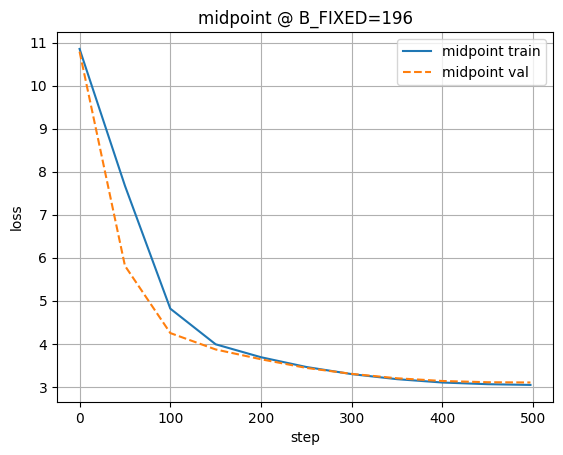

In [7]:
# --- Train at B_FIXED (shared equal-batch anchor) ---
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
model = ReversibleGPT(config, h=H, kind=KIND).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1, betas=(0.9, 0.95))
summary_f, hist_f = train(model, opt, B_FIXED, TOKENS, BLOCK_SIZE, LR, train_arr, val_arr,
                          rng, device, USE_AMP, CE_CHUNKS, KIND, variant=KIND, h=H)
print(json.dumps(summary_f, indent=2))
show_results([summary_f], [hist_f], f"{KIND} @ B_FIXED={B_FIXED}")


## 7. Maximum-batch probe and run

`find_max_batch()` performs a guarded binary search (probe 1, then doubling to the
cap, then bisection). The probe **cap is 1024**, so a returned value of 1024 is a
lower bound rather than the true maximum. The probed batch is then used for a
second training run over the same 50M-token budget; the shorter step count makes
this a memory/throughput comparison rather than a quality one.

  probe batch=8 ...
  probe batch=16 ...
  probe batch=32 ...
  probe batch=64 ...
  probe batch=128 ...
  probe batch=256 ...
  probe batch=512 ...
  probe batch=1024 ...
B_MAX[midpoint] = 1024
step     0/95 | loss 10.8537 | val 10.5766 | tok/s 26136 | mem 35281MB
step    25/95 | loss 8.7585 | val 10.5766 | tok/s 65015 | mem 35442MB
step    50/95 | loss 6.5571 | val 5.4388 | tok/s 64748 | mem 35442MB
step    75/95 | loss 5.5455 | val 5.4388 | tok/s 65574 | mem 35442MB
step    94/95 | loss 5.2058 | val 5.0156 | tok/s 65364 | mem 35442MB
{
  "run": "midpoint@B_MAX",
  "params_M": 20.11,
  "batch_size": 1024,
  "micro_batch": 1024,
  "grad_accum_steps": 1,
  "block_size": 512,
  "tokens": 49807360,
  "total_steps": 95,
  "warmup_steps": 9,
  "final_train_loss": 5.2058,
  "final_train_loss_last_batch": 4.9854,
  "final_val_loss": 5.0156,
  "avg_tok_per_sec": 65363.8,
  "peak_tok_per_sec": 75724.3,
  "peak_mem_mb": 35441.9,
  "wall_time_s": 762.0,
  "time_per_step_ms": 8021.07,
  "lr": 0.0

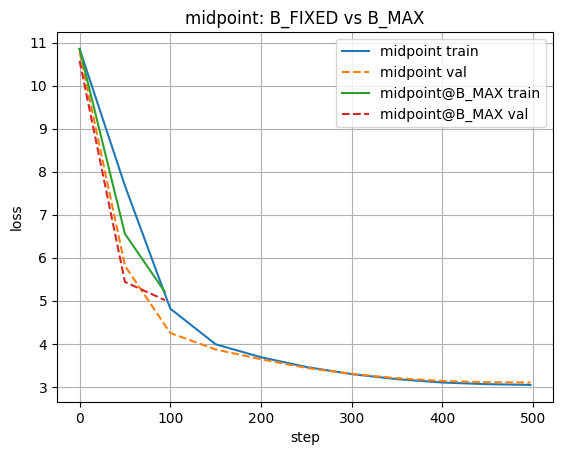

In [8]:
# --- Auto-detect B_MAX for this reversible variant, then train at it ---
torch.manual_seed(SEED)
probe_rng = np.random.default_rng(SEED + 999)
probe = ReversibleGPT(config, h=H, kind=KIND).to(device)
probe_opt = torch.optim.AdamW(probe.parameters(), lr=LR)
B_MAX = find_max_batch(probe, probe_opt, train_arr, BLOCK_SIZE, probe_rng,
                       device, USE_AMP, CE_CHUNKS)
print(f"B_MAX[{KIND}] = {B_MAX}")
del probe, probe_opt
if device.type == "cuda":
    torch.cuda.empty_cache()
assert B_MAX >= B_FIXED, (
    f"B_MAX={B_MAX} < B_FIXED={B_FIXED}: fix B_FIXED before trusting the comparison")

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
model = ReversibleGPT(config, h=H, kind=KIND).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1, betas=(0.9, 0.95))
summary_m, hist_m = train(model, opt, B_MAX, TOKENS, BLOCK_SIZE, LR, train_arr, val_arr,
                          rng, device, USE_AMP, CE_CHUNKS, f"{KIND}@B_MAX",
                          variant=KIND, h=H, B_MAX=B_MAX)
print(json.dumps(summary_m, indent=2))
show_results([summary_f, summary_m], [hist_f, hist_m], f"{KIND}: B_FIXED vs B_MAX")

# NOTE: the B_MAX run takes fewer optimizer steps than B_FIXED for the same 50M
# token budget (total_steps = tokens // (B*T)), so its loss is not directly
# comparable to B_FIXED. Treat B_MAX as a memory/throughput result.


## 8. Observations from Experiment 2

- Reversibility check `max|recon − forward|` = **1.59e-05**; custom-backward
  parity vs plain autograd = **3.0e-03** (fp32, `B=2, T=64`, outside
  autocast).
- Activation memory is flat in depth (~183 MB from 2 to 16 layers) versus
  189 → 248 MB for the plain residual stack.
- At `B_FIXED = 196` the stack peaks at **7,036 MB** vs **15,313 MB** for
  the baseline; final val loss **3.1011** at **88,346 tokens/s**.
- `B_MAX = 1024` (probe cap). The `@B_MAX` run uses the same 50M-token
  budget in 95 steps, so its loss is not comparable to the `B_FIXED` run.
- Of the three variants this one has the lowest loss: val **3.1011**
  vs baseline **3.1565**.